# Analyzing Team USA 2024 VNL Men's Volleyball Attack Stats

Introduction

This Dataset consists of all attacks made during the Volleyball National League in 2024.

Source: Jonathan P Moyer VNL 2024 - Men's Volleyball Stats (Kaggle)

--- Section 1: Introduction ---

This dataset was retrieved from Kaggle in which I was provided with every player's offensive stats who participated in the Volleyball Nations League(VNL) 2024. I decided to analyze specifically team USA and their offensive performance for that year as I wanted to develop a better understanding of how well the nation does at producing world class level volleyball players. Within this dataset I will be findining meaningful data that directs me towards a better understanding of how our current Volleyball program is doing. The reason I choose a volleyball dataset is highly due to my immense passion and enjoyment for the sport. Since I'm from the United States I only felt as though analyzing our national team would be fitting.


In [2]:
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
from scipy.stats import bernoulli
from scipy.stats import binom

In [3]:
vnl24 = pd.read_csv('VNL2024Men_Attackers.csv', encoding='latin1')
vnl24

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
0,T. Stern,SLO,265,68,153,17.67,54.53,486
1,Nimir,NED,235,81,138,19.58,51.76,454
2,Maar,CAN,194,59,150,14.92,48.14,403
3,Cebulj,SLO,179,63,149,11.93,45.78,391
4,Yant,CUB,167,49,98,13.92,53.18,314
...,...,...,...,...,...,...,...,...
289,Hatipoglu,TUR,0,0,0,NaN,NaN,0
290,Briggs,USA,0,0,0,NaN,NaN,0
291,Dagostino,USA,0,0,0,NaN,NaN,0
292,E. Shoji,USA,0,0,0,NaN,NaN,0


## EDA

--- Section 2: EDA ---
Based on the Data:

Success Rate Per Attack: 45.42%
Unsuccess Rate Per Attack: 41.41%
Error Rate Per Attack: 13.16%
Average Points a Match From Attacks: 40
Average Attack Error a Match: 11.73
MVP = TJ Defalco
LVP = Muagututia
Key Players: Defalco, Anderson, Ewert, Hanes, Jaeschke, Holt

Based on these stats we can confirm a few things. 2024 was not team USA's best year by far. Team USA had a success rate per attack below 50% being 45.42% with an error per attack being 13.15% costing the team an average of almost 12 points a match from simply offensive errors. Furthermore it can be identified that the team averages around 40 points from attacks per match. This number is significant as it demonstrates a lack in the teams offensive capabilities. Typically a team will need 75 points minimum in order to win a match in the VNL with the majority of those points typically coming from attacks. Team USA barely makes it past 50% of the needed points from their average points per match from attacks indicating a heavey dependency on serves and errors from the opposing team. This dependency is not favorable for perforance within the VNL.

Looking further into the dataset I was able to identify team USA's key 6 players for scoring points as well as their 6 players that seemed to be liabilities for the teams winning chances. From this we can concur that the team USA has a select few players that they should really focus on putting into their game while some others they would be better off training more before actually putting them into a game.

Overall team USA had a severe lack in offensive power and proficiency when particiapting in the 2024 VNL. However, they thankfully werent the worst out of the 16 participating countries. From this analysis it can be seen that there should be a much heavier emphasis placed on improving the overall offensive capabilities of the team. 



In [4]:
ttPLayers = vnl24.groupby('Team').agg('count').reset_index()
ttPLayers


,Team,Name,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
0,ARG,14,14,14,14,12,12,14
1,BRA,17,17,17,17,13,13,17
2,BUL,20,20,20,20,14,14,20
3,CAN,16,16,16,16,13,13,16
4,CUB,14,14,14,14,11,11,14
5,FRA,16,16,16,16,14,14,16
6,GER,22,22,22,22,18,18,22
7,IRI,17,17,17,17,13,13,17
8,ITA,24,24,24,24,16,16,24
9,JPN,17,17,17,17,14,14,17


In [5]:
vnl24.groupby('Team').agg('sum').reset_index()

,Team,Name,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
0,ARG,Lima B.PalonskyConteLoser BrunoZerbaVicentinKu...,662,193,516,50.94,560.27,1371
1,BRA,DarlanLucarelliLealAlanLucasFlavioAdrianoL. Be...,687,189,467,59.60,593.78,1343
2,BUL,TatarovDimitrovAsparuhovGrozdanovPetkovKaryagi...,491,204,411,48.00,694.34,1106
3,CAN,MaarLoeppkySzwarcMcCarthyVan BerkelWassenaar K...,670,174,484,51.67,630.14,1328
4,CUB,YantLopezConcepcionSanchez B.SimonMassoMergare...,647,184,391,53.95,480.38,1222
5,FRA,PatryClevenotLouatiFaureTillieLe GoffSeddikCar...,807,216,574,62.64,672.21,1597
6,GER,BrandKarlitzekReichertMaaseGrozerJohnKrickKrag...,602,208,487,73.27,768.85,1297
7,IRI,AminMiladPoriyaSalehiMortezaMohammadMoslehabad...,583,204,439,50.56,601.25,1226
8,ITA,MichielettoRomanoLaviaBovolentaPorro L.Bottolo...,621,148,427,77.17,868.28,1196
9,JPN,NishidaIshikawaMiyauraOtsukaOnoderaKaiRanYamau...,760,246,569,62.83,682.10,1575


In [6]:
# vnl24['ARG Avg Pt Per Attk'] = 

In [7]:
tUSA = vnl24[(vnl24.Team == 'USA')]
tUSA

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
28,Defalco,USA,96,29,56,12.00,53.04,181
48,Anderson,USA,70,18,97,8.75,37.84,185
81,Ewert,USA,52,22,60,6.50,38.81,134
82,Hanes,USA,52,13,30,7.43,54.74,95
97,Jaeschke,USA,38,6,29,9.50,52.05,73
101,Holt,USA,35,5,21,5.00,57.38,61
109,Averill,USA,31,2,17,3.88,62.00,50
124,Russell,USA,25,8,19,6.25,48.08,52
136,Ensing,USA,21,10,23,2.62,38.89,54
137,Jendryk,USA,21,2,26,2.62,42.86,49


In [8]:
oo = tUSA.groupby('Team').agg('sum').reset_index()
oo

,Team,Name,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
0,USA,DefalcoAndersonEwertHanesJaeschkeHoltAverillRu...,566,164,516,89.17,1095.39,1246


In [9]:
ptavg = oo['Pt_Attack']/oo['Tot_Attack']
ptavg

0    0.454254
dtype: float64

In [10]:
ptU = oo['Att_Attack']/oo['Tot_Attack']
ptU

0    0.414125
dtype: float64

In [11]:
ptavgatt = ptavg*oo['MAvg_Attack']
ptavgatt

0    40.505795
dtype: float64

In [12]:
atterr = oo['Err_Attack']/oo['Tot_Attack']
atterr

0    0.131621
dtype: float64

In [13]:
avgerr = atterr*oo['MAvg_Attack']
avgerr

0    11.736661
dtype: float64

In [14]:
# tUSA.nlargest(27, 'Tot_Attack')


In [15]:
tUSA.nlargest(6, 'Att_Attack')

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
48,Anderson,USA,70,18,97,8.75,37.84,185
81,Ewert,USA,52,22,60,6.50,38.81,134
28,Defalco,USA,96,29,56,12.00,53.04,181
82,Hanes,USA,52,13,30,7.43,54.74,95
97,Jaeschke,USA,38,6,29,9.50,52.05,73
147,Muagututia,USA,18,11,27,2.25,32.14,56


In [16]:
# tUSA.nlargest(27, 'Att_Attack')

In [17]:
tUSA.nlargest(6, 'Err_Attack')

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
28,Defalco,USA,96,29,56,12.00,53.04,181
81,Ewert,USA,52,22,60,6.50,38.81,134
48,Anderson,USA,70,18,97,8.75,37.84,185
82,Hanes,USA,52,13,30,7.43,54.74,95
147,Muagututia,USA,18,11,27,2.25,32.14,56
136,Ensing,USA,21,10,23,2.62,38.89,54


In [18]:
# tUSA.nlargest(27, 'Err_Attack')

In [19]:
tUSA.nlargest(6, 'Pt_Attack')

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
28,Defalco,USA,96,29,56,12.00,53.04,181
48,Anderson,USA,70,18,97,8.75,37.84,185
81,Ewert,USA,52,22,60,6.50,38.81,134
82,Hanes,USA,52,13,30,7.43,54.74,95
97,Jaeschke,USA,38,6,29,9.50,52.05,73
101,Holt,USA,35,5,21,5.00,57.38,61


In [20]:
tUSA.nsmallest(6, 'p_Attack')

,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack
293,Ma'a,USA,0,0,2,0.00,0.00,2
168,Champlin,USA,11,6,19,2.75,30.56,36
147,Muagututia,USA,18,11,27,2.25,32.14,56
219,Tuaniga,USA,1,0,2,0.25,33.33,3
220,Wetter,USA,1,0,2,0.25,33.33,3
150,Kessel,USA,17,6,27,2.83,34.00,50


### Data Visulaization

--- Section 3: Visualization ---

In [21]:
# tUSA.plot.hexbin(x = 'Pt_Attack', y = 'Att_Attack', gridsize = 25)

<Axes: title={'center': 'Average Attacks Per Match'}, xlabel='Name'>

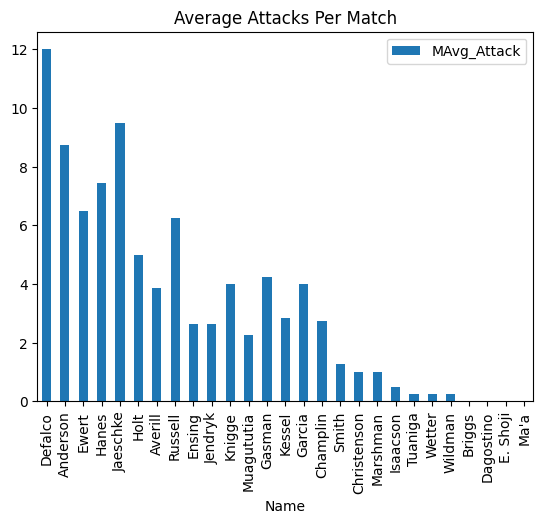

In [22]:
tUSA.plot.bar(y='MAvg_Attack', x='Name', title='Average Attacks Per Match')

This bar plot allows us to see the relation of attacks per game to the success rate given in the graphs below. In this graph it can be identified that there a few players that are getting set the ball a lot more but in return gaining less points for the team.

<Axes: title={'center': 'Attack Success Rate'}, xlabel='Name'>

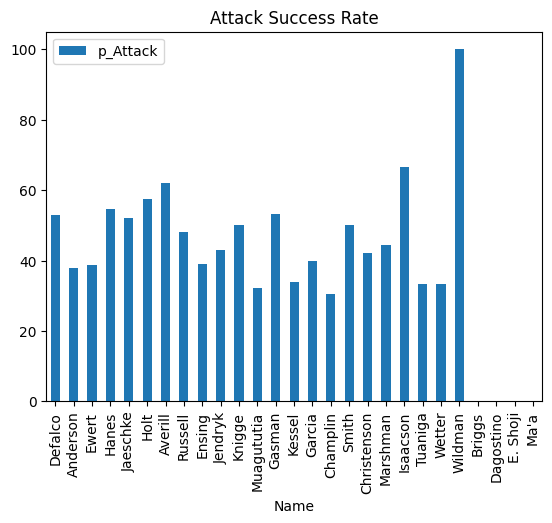

In [23]:
tUSA.plot.bar(y='p_Attack', x='Name', title='Attack Success Rate')

This bar plot allows us to visualize the relationship of attack success rate in relation to the overall sets each player gets and the amount of points they score for the team. With this visualization we are able to uncover certain facotrs that may help to identfiy which players are being played a bit too much giving the team less points than what some other players who are not getting enough play time could be giving.

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

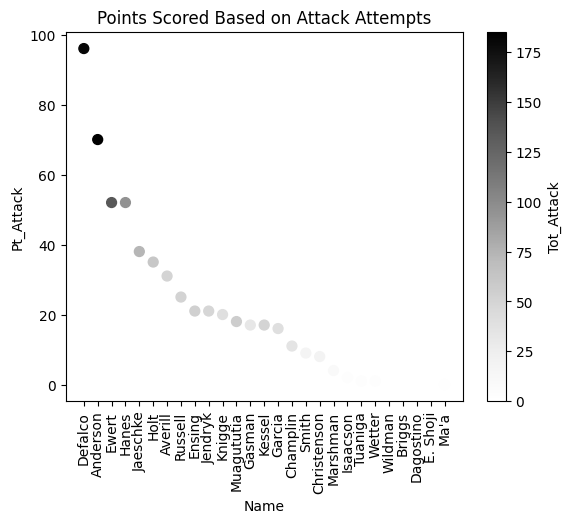

In [24]:
tUSA.plot.scatter(x='Name',y='Pt_Attack',c='Tot_Attack', title='Points Scored Based on Attack Attempts', s=50)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)

This scatterplot helps show how successful players attacks are helping us to identify which players tend to be the most reliable. From the graph it can be identified that the three most key offensive scorers are Defalco, Anderson, and Ewert.

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

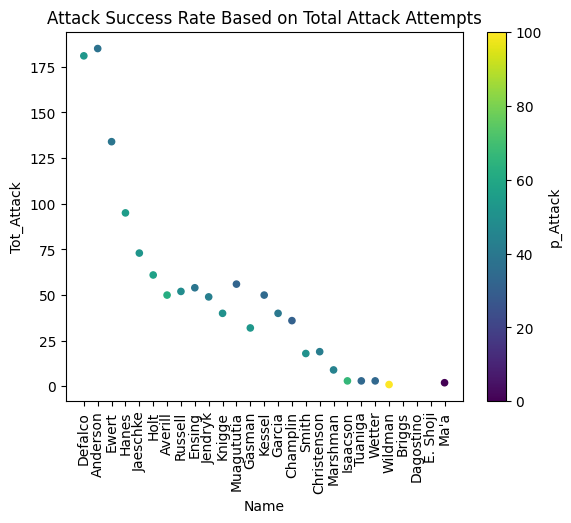

In [25]:
tUSA.plot.scatter(x = 'Name',y='Tot_Attack', c='p_Attack', title='Attack Success Rate Based on Total Attack Attempts')
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)

This scatterplot represents the success rate of each players attack attempts. By visualizing this data we are able to identify which players follow a positive trend with the consistency of scoring while in relation to the amount of attempts they have. In addition we can also identify which players had less play time but performed well where as some players recieved more play time with poor performances.

#### PLanning for Part 2

---Section 4: Data Science---

After filtering out the data and identifying the key aspects of my set I've been able to confirm a few things. First observation would be the poor performance that the USA Men's National Volleyball team had during the VNL 2024. Based on the statistics the team consistenly underperformed offensively generating a lot of costly errors as well as unsuccessful attack attempts. Based on the filtration I was able to find that the average points per match that the team earned was barely over the 50% mark for the necessary needed points to win a VNL match. This statistic paired with the fact that the rate of success per attack attempt was significanlty below 50% coming in at 45.42% paired with an error rate of 13%; it can be seen that team USA has a lot of room for improvement when it comes to their offensive capabilites. 

Further more through this study I was able to observe a few key players and not so key players. The top 3 scorers stayed consistent with all their other statistics leading them to be the most reliable and beneficial players offensively for the team. These players consisted of Deflaco, Anderson, and Ewertm with the most liable players being Muagututia, Kessel, and Champlin.

Continuing my study I would like to identify a few more important factors for my overall understanding of Team USA's offensive capabilities. This will include a deeper dive into the respective players and their performance compared to that of other teams and their match ups. I will also be taking into consideration the coach during that time as compared to the coach now. Through this analysis I will be able to formulate sufficient data for a prediction model. I will use this prediction model to identify whether or not certain players should be kept in for the next season or taken off the roster.In addition I would like to see how the current team USA compares to that of team USA 2024.

##### Answering The Question

---Section 5: Data Science Continuation---

Furthering my study of the dataset I've chosen to answer the question, "which players do more harm then good for the team". This question will allow for us to identify which players are contributing to the team and which players are taking away from the team based on their play time and game stats. I will be able to answer this question utilizing a machine learning model. In order to train this model I will need a few pieces of information. 

In [26]:
tUSA['attack_efficiency'] = (tUSA.Pt_Attack-tUSA.Err_Attack)/tUSA.Tot_Attack
# tUSA

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\655118511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tUSA['attack_efficiency'] = (tUSA.Pt_Attack-tUSA.Err_Attack)/tUSA.Tot_Attack


In [27]:
tUSA['error_rate'] = tUSA.Err_Attack/tUSA.Tot_Attack
# tUSA

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\1545553044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tUSA['error_rate'] = tUSA.Err_Attack/tUSA.Tot_Attack


In [28]:
tUSA['success_prob'] = tUSA['Pt_Attack']/tUSA['Tot_Attack']
# tUSA

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\2332307937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tUSA['success_prob'] = tUSA['Pt_Attack']/tUSA['Tot_Attack']


In [29]:
threshold = tUSA.attack_efficiency.quantile(.25)
tUSA['harmful'] = (tUSA['attack_efficiency'] < threshold).astype(int)
tUSA
# tUSA['harmful'] = (tUSA['error_rate'] > .18).astype(int)
# tUSA

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\2163760018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tUSA['harmful'] = (tUSA['attack_efficiency'] < threshold).astype(int)


,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack,attack_efficiency,error_rate,success_prob,harmful
28,Defalco,USA,96,29,56,12.00,53.04,181,0.370166,0.160221,0.530387,0
48,Anderson,USA,70,18,97,8.75,37.84,185,0.281081,0.097297,0.378378,0
81,Ewert,USA,52,22,60,6.50,38.81,134,0.223881,0.164179,0.388060,0
82,Hanes,USA,52,13,30,7.43,54.74,95,0.410526,0.136842,0.547368,0
97,Jaeschke,USA,38,6,29,9.50,52.05,73,0.438356,0.082192,0.520548,0
101,Holt,USA,35,5,21,5.00,57.38,61,0.491803,0.081967,0.573770,0
109,Averill,USA,31,2,17,3.88,62.00,50,0.580000,0.040000,0.620000,0
124,Russell,USA,25,8,19,6.25,48.08,52,0.326923,0.153846,0.480769,0
136,Ensing,USA,21,10,23,2.62,38.89,54,0.203704,0.185185,0.388889,1
137,Jendryk,USA,21,2,26,2.62,42.86,49,0.387755,0.040816,0.428571,0


In [30]:
tUSA['good'] = (tUSA['attack_efficiency'] > threshold).astype(int)
tUSA

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\3582002376.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tUSA['good'] = (tUSA['attack_efficiency'] > threshold).astype(int)


,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack,attack_efficiency,error_rate,success_prob,harmful,good
28,Defalco,USA,96,29,56,12.00,53.04,181,0.370166,0.160221,0.530387,0,1
48,Anderson,USA,70,18,97,8.75,37.84,185,0.281081,0.097297,0.378378,0,1
81,Ewert,USA,52,22,60,6.50,38.81,134,0.223881,0.164179,0.388060,0,1
82,Hanes,USA,52,13,30,7.43,54.74,95,0.410526,0.136842,0.547368,0,1
97,Jaeschke,USA,38,6,29,9.50,52.05,73,0.438356,0.082192,0.520548,0,1
101,Holt,USA,35,5,21,5.00,57.38,61,0.491803,0.081967,0.573770,0,1
109,Averill,USA,31,2,17,3.88,62.00,50,0.580000,0.040000,0.620000,0,1
124,Russell,USA,25,8,19,6.25,48.08,52,0.326923,0.153846,0.480769,0,1
136,Ensing,USA,21,10,23,2.62,38.89,54,0.203704,0.185185,0.388889,1,0
137,Jendryk,USA,21,2,26,2.62,42.86,49,0.387755,0.040816,0.428571,0,1


In [31]:
tusa = tUSA.dropna()
# tusa

In [32]:
X = tusa[['Pt_Attack', 'Err_Attack','Att_Attack','Tot_Attack','attack_efficiency','error_rate','success_prob']]
y = tusa['harmful']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
#predicting

tusa['harmful_prediction'] = model.predict(X)
tusa[['Name','Team','harmful_prediction']].head()

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\252840676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tusa['harmful_prediction'] = model.predict(X)


,Name,Team,harmful_prediction
28,Defalco,USA,0
48,Anderson,USA,0
81,Ewert,USA,0
82,Hanes,USA,0
97,Jaeschke,USA,0


In [34]:
pd.set_option('display.float_format','{:.4f}'.format)
tusa['harm_probability'] = model.predict_proba(X)[:,1]
harmful_ranked = tusa.sort_values('harm_probability',ascending=False)
harmful_ranked

C:\Users\asher\AppData\Local\Temp\ipykernel_9860\1722470982.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tusa['harm_probability'] = model.predict_proba(X)[:,1]


,Name,Team,Pt_Attack,Err_Attack,Att_Attack,MAvg_Attack,p_Attack,Tot_Attack,attack_efficiency,error_rate,success_prob,harmful,good,harmful_prediction,harm_probability
147,Muagututia,USA,18,11,27,2.2500,32.1400,56,0.1250,0.1964,0.3214,1,0,1,0.9340
168,Champlin,USA,11,6,19,2.7500,30.5600,36,0.1389,0.1667,0.3056,1,0,1,0.9177
150,Kessel,USA,17,6,27,2.8300,34.0000,50,0.2200,0.1200,0.3400,1,0,1,0.7899
293,Ma'a,USA,0,0,2,0.0000,0.0000,2,0.0000,0.0000,0.0000,1,0,1,0.5306
220,Wetter,USA,1,0,2,0.2500,33.3300,3,0.3333,0.0000,0.3333,0,1,0,0.2536
219,Tuaniga,USA,1,0,2,0.2500,33.3300,3,0.3333,0.0000,0.3333,0,1,0,0.2536
193,Marshman,USA,4,1,4,1.0000,44.4400,9,0.3333,0.1111,0.4444,0,1,0,0.0784
221,Wildman,USA,1,0,0,0.2500,100.0000,1,1.0000,0.0000,1.0000,0,1,0,0.0631
48,Anderson,USA,70,18,97,8.7500,37.8400,185,0.2811,0.0973,0.3784,0,1,0,0.0542
176,Christenson,USA,8,2,9,1.0000,42.1100,19,0.3158,0.1053,0.4211,0,1,0,0.0517


In [39]:
# sns.lmplot(data=tusa, x='harm_probability', y='Name')

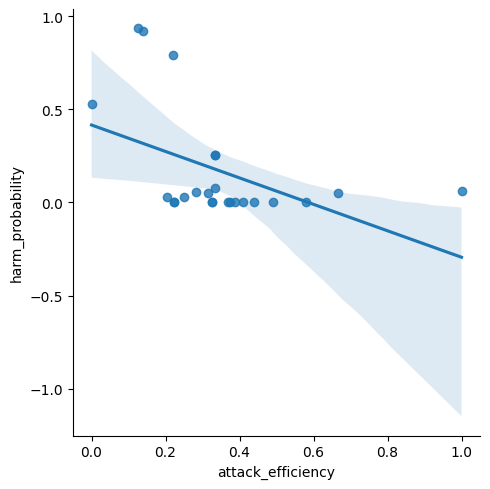

In [37]:
sns.lmplot(data = tusa, x='attack_efficiency', y='harm_probability')

###### Overall Summary

---Section 6: Final Statement---

From this study I was able to successfully identify and predict potential players that may be a liability to team USA's success. While working towards my final conclusion I was able to identify and visualize which players had less play time but contributed a suprising amount of points to the team. For example it was shown that players like Averill and Isaacson have a suprisingly high success rate on scoring a point per attack attempt. This is further reinforced with the data visualization helping to indicate a potential starting player or key player for the team in the future. In order to verify my findings I created a few more visualizations to develop a better understanding of which players had the most impact on the team. Whether it be positive or not these visualizations such as, "Average Attacks Per Match" compared to "Points Scored Based On Attack Attempts", severly helped with creating a more rounded understanding of which players were doing more harm than good. To add and figure out which players were the most harmful to the data frame I used python to develop a function that would give a player a 1 based on if the players harm statistics surpassed a certain threshold. From this function I was able to obtain the necessary information needed to train a machine learning model. Through this model I was able to visualize and identify which players were harming the team based on there match statistics and whether or not more players will start to harm the team rather than benefit the team in the future. Through this model I was able to answer my part 2 question on whether or not certain players should get less play time rather than others.

The players that have shown to perform quite poorly on the international stage and have a high harm chance are, Muagututia, Kessel, and Champlin. These players had gotten a decent amount of playtime but unfortunately couldn't make the most out of that time. From this I can confidently conclude that the current starting players are and will be consistent and good for the team for years to come. However, when the teams coach does choose to sub in certain players, he should really reconsider which players benefit the team more.